In [1]:
from rasterio.transform import from_bounds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from inference_engine import InferenceEngine, predict_with_confidence
from pathlib import Path
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine

# ── Visual constants ──────────────────────────────────────────────────────────
FLOOD_COLORS = {
     0: '#FFFFFF',
     1: '#C6DBEF',
     2: '#6BAED6',
     3: '#2171B5',
     4: '#08306B',
}
FLOOD_LABELS = {0:'No Flood', 1:'Light', 2:'Moderate', 3:'Heavy', 4:'Extreme'}

# Mask -1 values so they render as fully transparent
flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_cmap.set_bad(alpha=0)                          # -1 → transparent
flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5)

legend_patches = [
    mpatches.Patch(color=FLOOD_COLORS[i], label=FLOOD_LABELS[i]) for i in range(5)
]

flood_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 6)

def masked_flood(flood_map):
    return np.ma.masked_where(flood_map < 0, flood_map)

# ── Class percentage helper ───────────────────────────────────────────────────
def compute_class_pcts(flood_map):
    """Percentages over valid (non -1) patches only."""
    valid = flood_map[flood_map >= 0]
    total = len(valid)
    return {i: 100 * (valid == i).sum() / total if total > 0 else 0.0
            for i in range(5)}

# ── GeoTIFF save helper ───────────────────────────────────────────────────────
dem_crs       = rasterio.crs.CRS.from_epsg(3857)
dem_transform = Affine(30.0, 0.0, 13462980.0, 0.0, -30.0, 1647690.0)

def save_prediction_tiff(result, engine, save_path: str, bounds=None, crs: str = 'EPSG:32651'):
    flood_map  = result['flood_map'].astype(np.float32)
    confidence = result['confidence']

    conf_map = np.full(flood_map.shape, fill_value=-1.0, dtype=np.float32)  # -1 = nodata
    for conf_val, (r, c) in zip(confidence, engine.patch_indices):
        conf_map[r:r + 4, c:c + 4] = float(conf_val)

    H, W = flood_map.shape

    if bounds:
        transform = from_bounds(*bounds, W, H)
    else:
        transform = rasterio.transform.from_origin(0, H, 1, 1)

    with rasterio.open(
        save_path, 'w',
        driver='GTiff', height=H, width=W, count=2,
        dtype='float32', crs=crs, transform=transform,
        nodata=-1.0,                                   # -1 = transparent in QGIS/ArcGIS
    ) as dst:
        dst.write(flood_map, 1)
        dst.write(conf_map,  2)
        dst.update_tags(
            BAND_1='Flood class (0=No Flood, 1=Light, 2=Moderate, 3=Heavy, 4=Extreme)',
            BAND_2='Prediction confidence (0.0 - 1.0)',
            STORM_LABEL=result.get('storm_label', ''),
        )
    print(f"✓ Saved → {save_path}")

def visualize_prediction_tiff(tiff_path: str, title: str = None, figsize=(14, 6)):
    with rasterio.open(tiff_path) as src:
        flood_map = src.read(1)
        conf_map  = src.read(2)
        bounds    = src.bounds

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Mask nodata (-1) → renders transparent
    nodata_mask  = flood_map < 0
    flood_masked = np.ma.masked_where(nodata_mask, flood_map)
    conf_masked  = np.ma.masked_where(nodata_mask, conf_map)

    # ── Band 1: Flood class map ───────────────────────────────────────────────
    cmap_flood = mcolors.ListedColormap(['#FFFFFF', '#C6DBEF', '#6BAED6',
                                          '#2171B5', '#08306B'])
    cmap_flood.set_bad(alpha=0)                        # transparent outside Manila
    norm_flood = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5)

    axes[0].imshow(flood_masked, cmap=cmap_flood, norm=norm_flood,
                   extent=extent, interpolation='nearest', aspect='equal')
    axes[0].set_title('Predicted Flood Class', fontsize=12, fontweight='bold')
    axes[0].tick_params(labelsize=7)

    patches = [mpatches.Patch(color=c, label=l) for c, l in zip(
        ['#FFFFFF', '#C6DBEF', '#6BAED6', '#2171B5', '#08306B'],
        ['No Flood', 'Light', 'Moderate', 'Heavy', 'Extreme']
    )]
    axes[0].legend(handles=patches, loc='lower right', fontsize=7)

    # ── Band 2: Confidence map ────────────────────────────────────────────────
    cmap_conf = plt.cm.RdYlGn.copy()
    cmap_conf.set_bad(alpha=0)                         # transparent outside Manila

    im2 = axes[1].imshow(conf_masked, cmap=cmap_conf, vmin=0, vmax=1,
                          extent=extent, interpolation='nearest', aspect='equal')
    axes[1].set_title('Prediction Confidence', fontsize=12, fontweight='bold')
    axes[1].tick_params(labelsize=7)

    cbar = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Confidence', fontsize=9)

    # ── Stats annotation ──────────────────────────────────────────────────────
    valid_conf = conf_map[~nodata_mask]
    stats_text = (f"Mean conf: {valid_conf.mean():.3f}  "
                  f"Low(<0.5): {(valid_conf < 0.5).mean()*100:.1f}%")
    fig.text(0.5, 0.01, stats_text, ha='center', fontsize=9, style='italic')

    fig.suptitle(title or tiff_path, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

[InferenceEngine] device = cpu
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Auto-selected: fold_1_best.pth  (macro_f1=0.4610)
[InferenceEngine] Model loaded  ← fold_1_best.pth

  Predicting: Front-Loaded, 20 mm
  Conditioning: pattern_type=0  depth_norm=0.205  tpeak=0.00  has_tpeak=0

  Flooded area : 5.5%  (332 / 6,075 patches)
  Mean confidence : 0.671

  Class           Count       %   Avg conf
  ------------------------------------------
  No Flood        5,743   94.5%      0.685
  Light               6    0.1%      0.355
  Moderate           66    1.1%      0.381
  Heavy             149    2.5%      0.378
  Extreme           111    1.8%      0.521
✓ Saved → outputs\predictions\front_loaded_20mm.tif
  ✓ front_loaded_20mm

  Predicting: Front-Loaded, 35 mm
  Conditioning: pattern_type=0  depth_norm=0.411  tpeak=0.00  has_tpeak=0

  Flooded area : 31.5%  (1,916 / 6,075 patches)
  Mean confidence : 0.638

  Class       

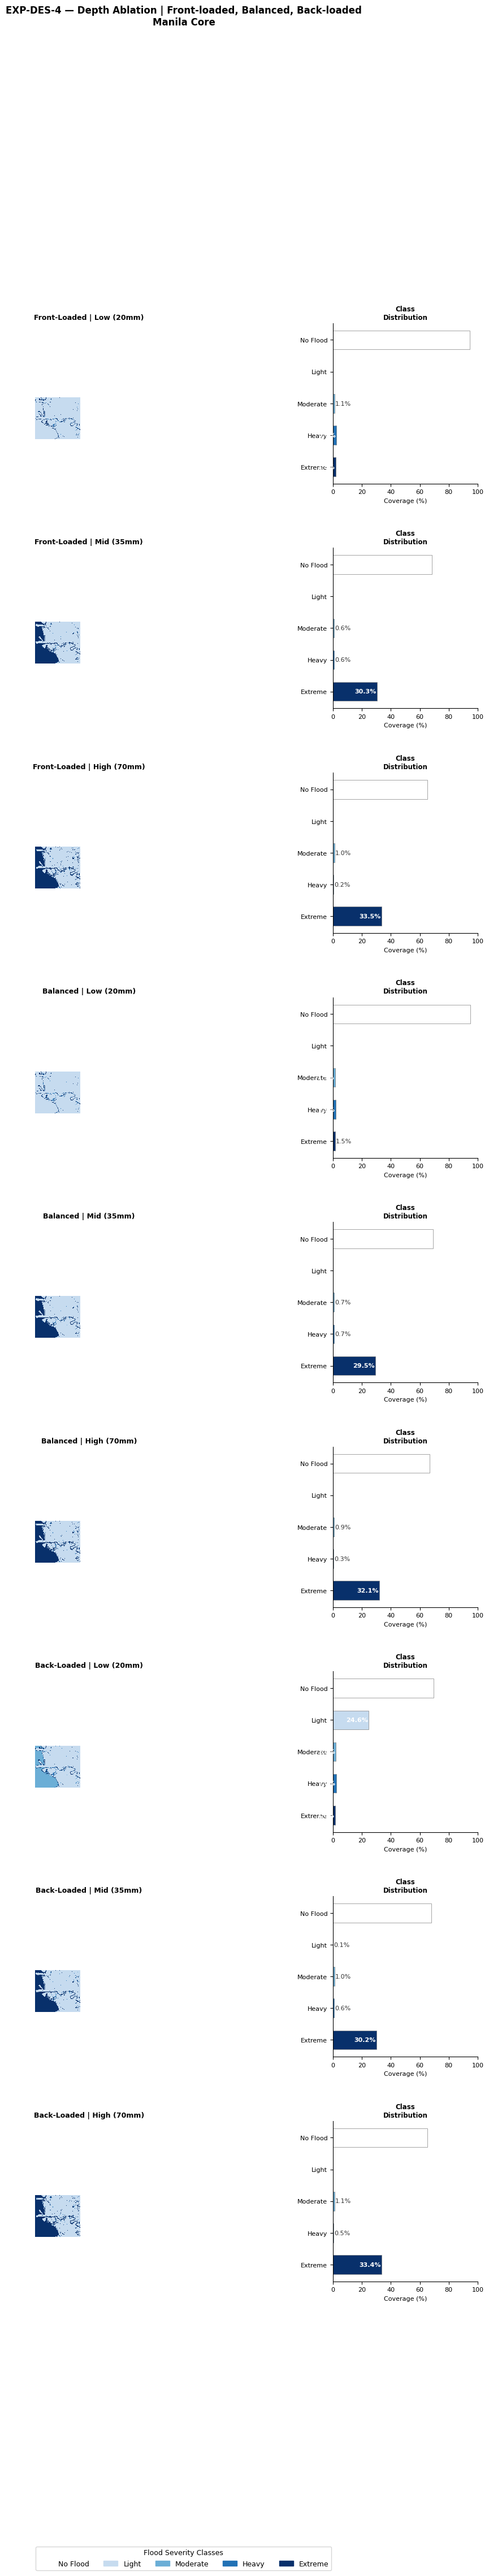

✓ Figure 1 saved


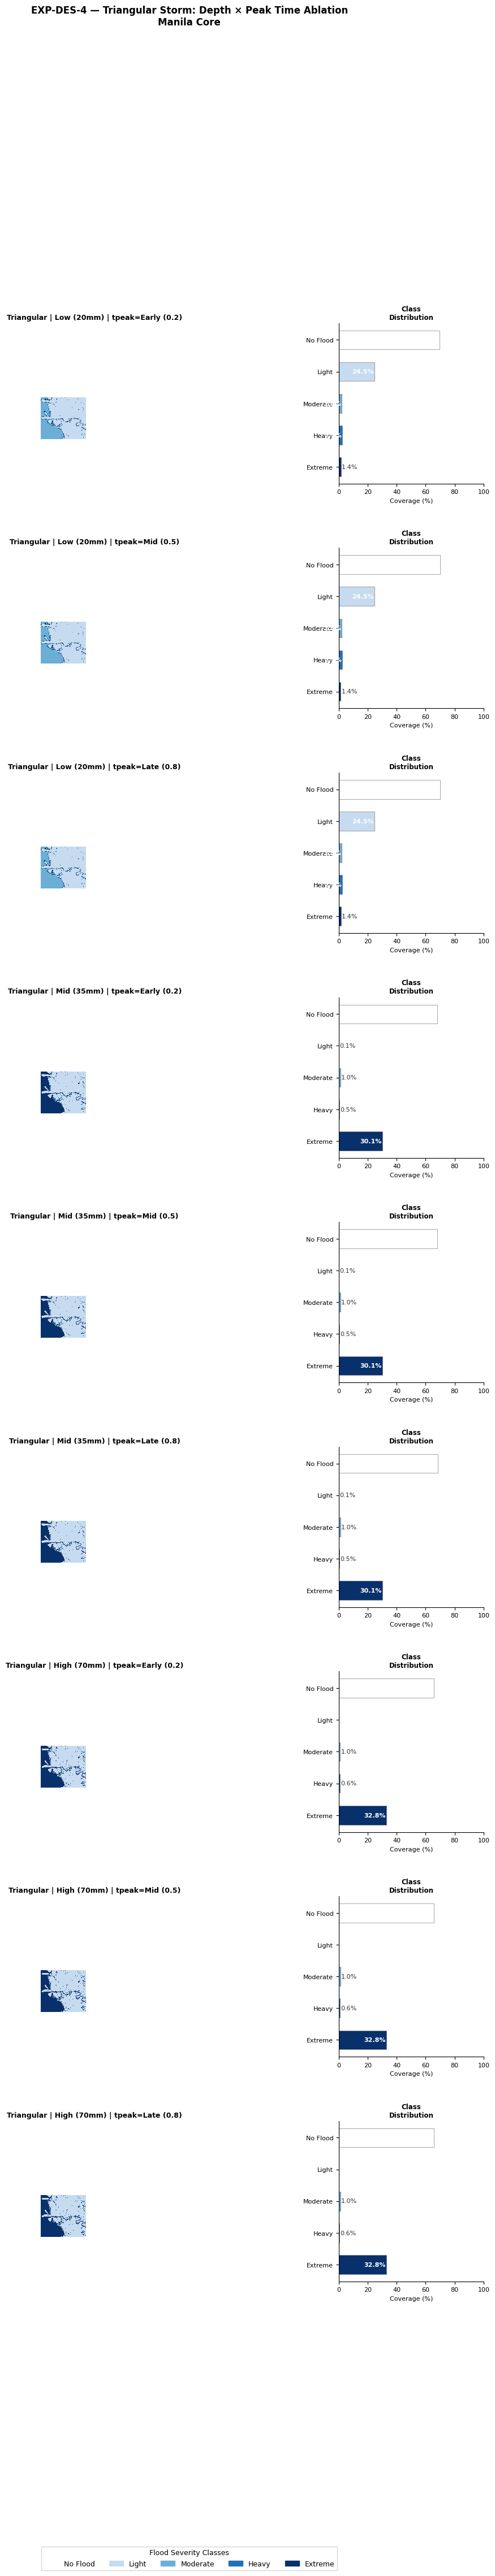

✓ Figure 2 saved

DEPTH / TPEAK ABLATION SUMMARY

  Front-Loaded
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ------------------------------------------------------------------------------
  Low (20mm)         0.6708       30.7%     94.5%    0.1%   1.1%    2.5%      1.8%
  Mid (35mm)         0.6377       29.3%     68.5%    0.0%   0.6%    0.6%     30.3%
  High (70mm)        0.5669       47.6%     65.3%    0.0%   1.0%    0.2%     33.5%

  Balanced
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ------------------------------------------------------------------------------
  Low (20mm)         0.6732       30.7%     94.9%    0.1%   1.5%    1.9%      1.5%
  Mid (35mm)         0.6494       29.1%     69.1%    0.1%   0.7%    0.7%     29.5%
  High (70mm)        0.5903       32.7%     66.7%    0.0%   0.9%    0.3%     32.1%

  Back-Loaded
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%

In [2]:

engine = InferenceEngine(patch_data_path = 'outputs/test_patches.npz')

# ══════════════════════════════════════════════════════════════════════════════
# DEPTH & TPEAK ABLATION — ALL 4 STORM TYPES
# No hasDrainage / hasSoil toggles (exp-des-4 uses 3 base channels only)
#
# Depth levels chosen to span the training range (6mm–78mm):
#   Low  : ~20mm  (light rainfall, near training minimum)
#   Mid  : ~35mm  (moderate, well-represented in all storm types)
#   High : ~70mm  (heavy, near training maximum)
#
# Triangular also varies tpeak: 0.2 (early), 0.5 (mid), 0.8 (late)
# giving a 3×3 grid of depth × tpeak for that storm type.
# ══════════════════════════════════════════════════════════════════════════════

DEPTHS  = [20, 35, 70]
TPEAKS  = [0.2, 0.5, 0.8]

DEPTH_LABELS = {20: 'Low (20mm)', 35: 'Mid (35mm)', 70: 'High (70mm)'}
TPEAK_LABELS = {0.2: 'Early (0.2)', 0.5: 'Mid (0.5)', 0.8: 'Late (0.8)'}

output_dir = Path('outputs/predictions')
output_dir.mkdir(parents=True, exist_ok=True)

# ── Storage ───────────────────────────────────────────────────────────────────
# results_depth[storm_type][depth_mm]       = result  (front/balanced/back-loaded)
# results_tri[depth_mm][tpeak]              = result  (triangular)

results_depth = {st: {} for st in ['front-loaded', 'balanced', 'back-loaded']}
results_tri   = {d:  {} for d  in DEPTHS}

# ── Run predictions ───────────────────────────────────────────────────────────
# Non-triangular: depth ablation only
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        result = predict_with_confidence(
            engine, storm_type=storm_type, depth_mm=depth
        )
        results_depth[storm_type][depth] = result
        slug = f"{storm_type.replace('-','_')}_{depth}mm"
        save_prediction_tiff(result, engine, str(output_dir / f'{slug}.tif'))
        print(f'  ✓ {slug}')

# Triangular: depth × tpeak grid
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result = predict_with_confidence(
            engine, storm_type='triangular', depth_mm=depth, tpeak=tpeak
        )
        results_tri[depth][tpeak] = result
        slug = f"triangular_{depth}mm_tpeak{str(tpeak).replace('.','')}"
        save_prediction_tiff(result, engine, str(output_dir / f'{slug}.tif'))
        print(f'  ✓ {slug}')

print(f'\n✓ All predictions saved → {output_dir}')

# ── Figure 1: Depth ablation — front-loaded, balanced, back-loaded ────────────
# Layout: 3 storm types × 3 depths = 9 rows, 2 cols (flood map | bar)
fig1, axes1 = plt.subplots(9, 2, figsize=(13, 45), gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25})
row = 0
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        result   = results_depth[storm_type][depth]
        ax_flood = axes1[row, 0]
        ax_bar   = axes1[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(f'{storm_type.title()} | {DEPTH_LABELS[depth]}',
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()
        row += 1

fig1.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
            frameon=True, title='Flood Severity Classes', title_fontsize=9,
            bbox_to_anchor=(0.5, -0.005))
fig1.suptitle(
    'EXP-DES-4 — Depth Ablation | Front-loaded, Balanced, Back-loaded\nManila Core',
    fontsize=12, fontweight='bold', y=1.005)
plt.savefig(str(output_dir / 'ablation_depth_non_triangular.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure 1 saved')


# ── Figure 2: Triangular depth × tpeak grid ───────────────────────────────────
# Layout: 9 combos (3 depths × 3 tpeaks) rows, 2 cols (flood map | bar)
fig2, axes2 = plt.subplots(
    9, 2, figsize=(13, 45),
    gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25}
)
row = 0
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result   = results_tri[depth][tpeak]
        ax_flood = axes2[row, 0]
        ax_bar   = axes2[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(
            f'Triangular | {DEPTH_LABELS[depth]} | tpeak={TPEAK_LABELS[tpeak]}',
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()
        row += 1

fig2.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
            frameon=True, title='Flood Severity Classes', title_fontsize=9,
            bbox_to_anchor=(0.5, -0.005))
fig2.suptitle(
    'EXP-DES-4 — Triangular Storm: Depth × Peak Time Ablation\nManila Core',
    fontsize=12, fontweight='bold', y=1.005)
plt.savefig(str(output_dir / 'ablation_triangular_depth_tpeak.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure 2 saved')


# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '='*75)
print('DEPTH / TPEAK ABLATION SUMMARY')
print('='*75)

# Non-triangular
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    print(f'\n  {storm_type.title()}')
    print(f'  {"Depth":<16} {"AvgConf":>8} {"Uncertain%":>11} '
          f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
    print(f'  {"-"*78}')
    for depth in DEPTHS:
        result      = results_depth[storm_type][depth]
        patch_confs = result['confidence']
        pcts        = compute_class_pcts(result['flood_map'])
        print(f'  {DEPTH_LABELS[depth]:<16} '
              f'{patch_confs.mean():>8.4f} '
              f'{100*(patch_confs<0.5).mean():>10.1f}% '
              f'{pcts[0]:>8.1f}% '
              f'{pcts[1]:>6.1f}% '
              f'{pcts[2]:>5.1f}% '
              f'{pcts[3]:>6.1f}% '
              f'{pcts[4]:>8.1f}%')

# Triangular
print(f'\n  Triangular')
print(f'  {"Depth × tpeak":<22} {"AvgConf":>8} {"Uncertain%":>11} '
      f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
print(f'  {"-"*84}')
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result      = results_tri[depth][tpeak]
        patch_confs = result['confidence']
        pcts        = compute_class_pcts(result['flood_map'])
        label       = f'{DEPTH_LABELS[depth]} | tp={tpeak}'
        print(f'  {label:<22} '
              f'{patch_confs.mean():>8.4f} '
              f'{100*(patch_confs<0.5).mean():>10.1f}% '
              f'{pcts[0]:>8.1f}% '
              f'{pcts[1]:>6.1f}% '
              f'{pcts[2]:>5.1f}% '
              f'{pcts[3]:>6.1f}% '
              f'{pcts[4]:>8.1f}%')

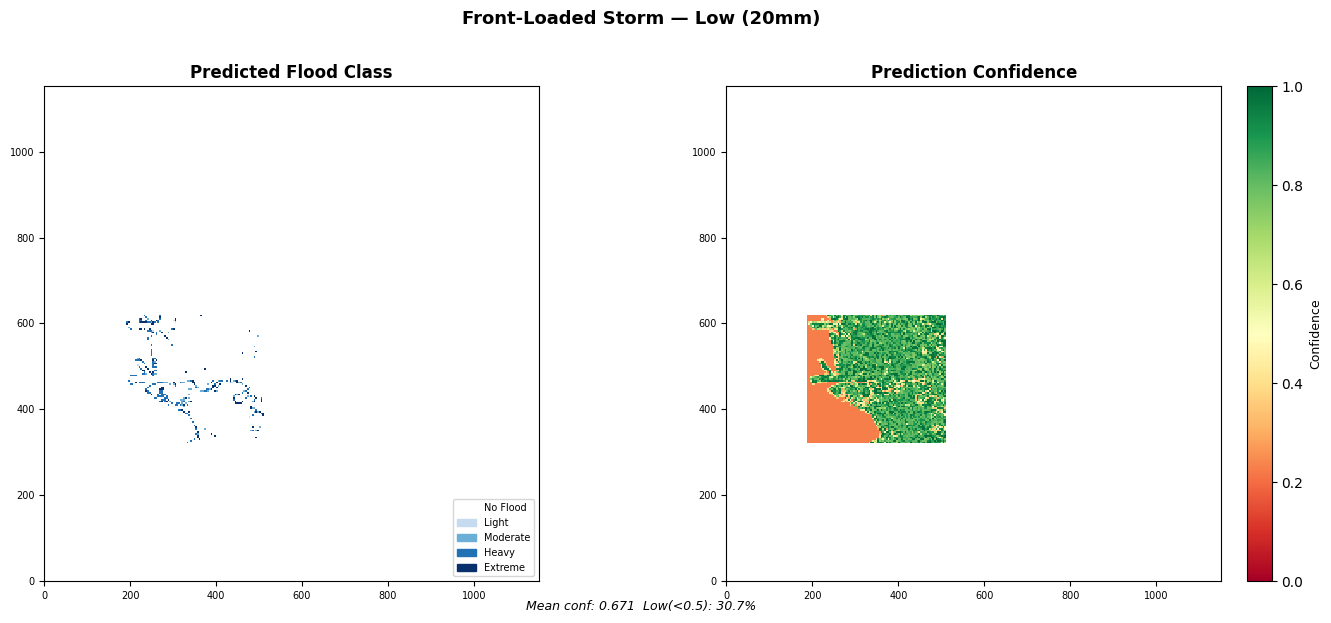

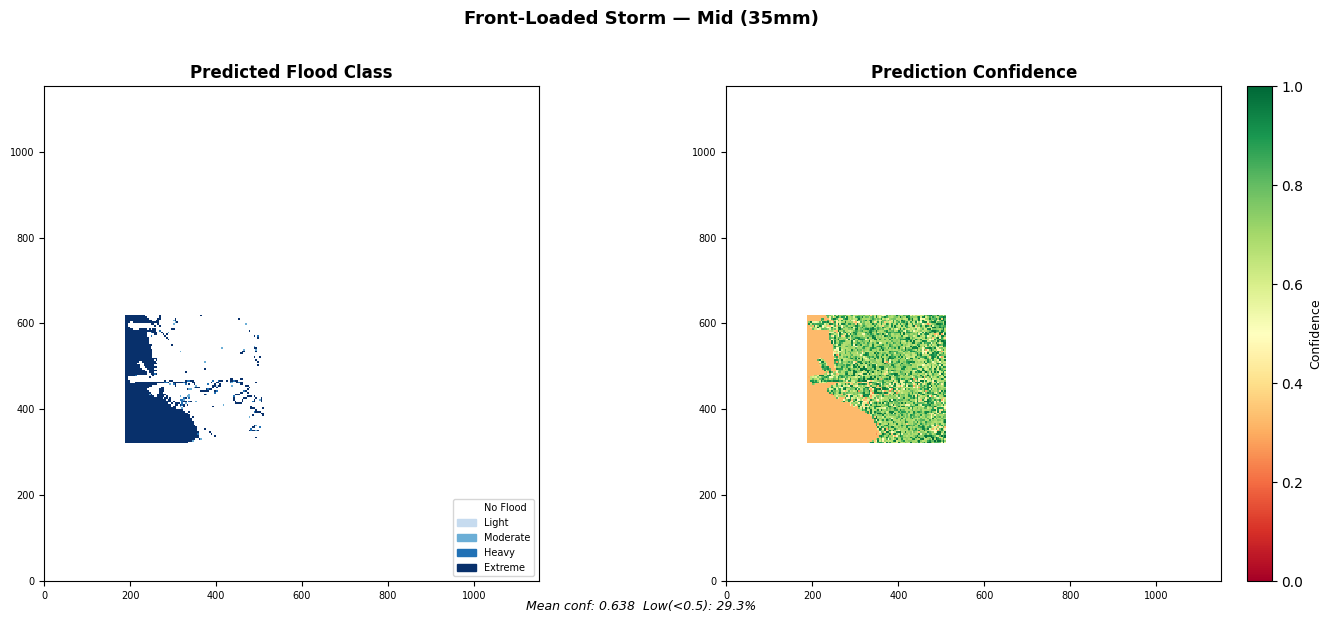

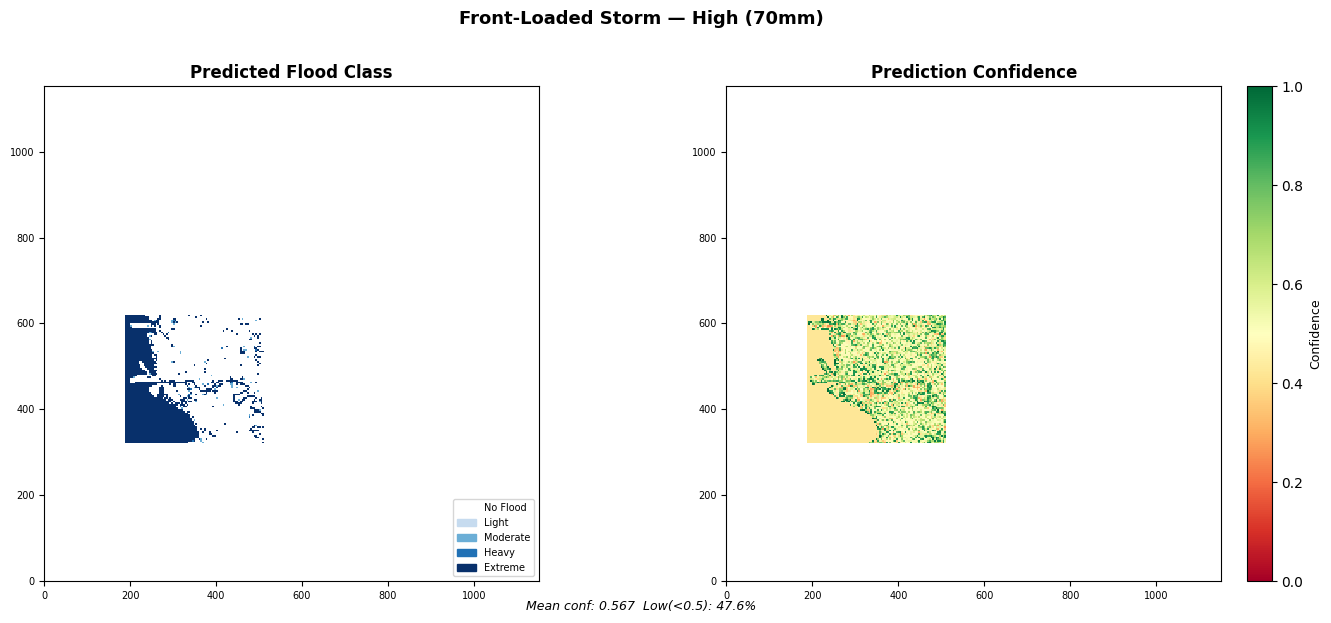

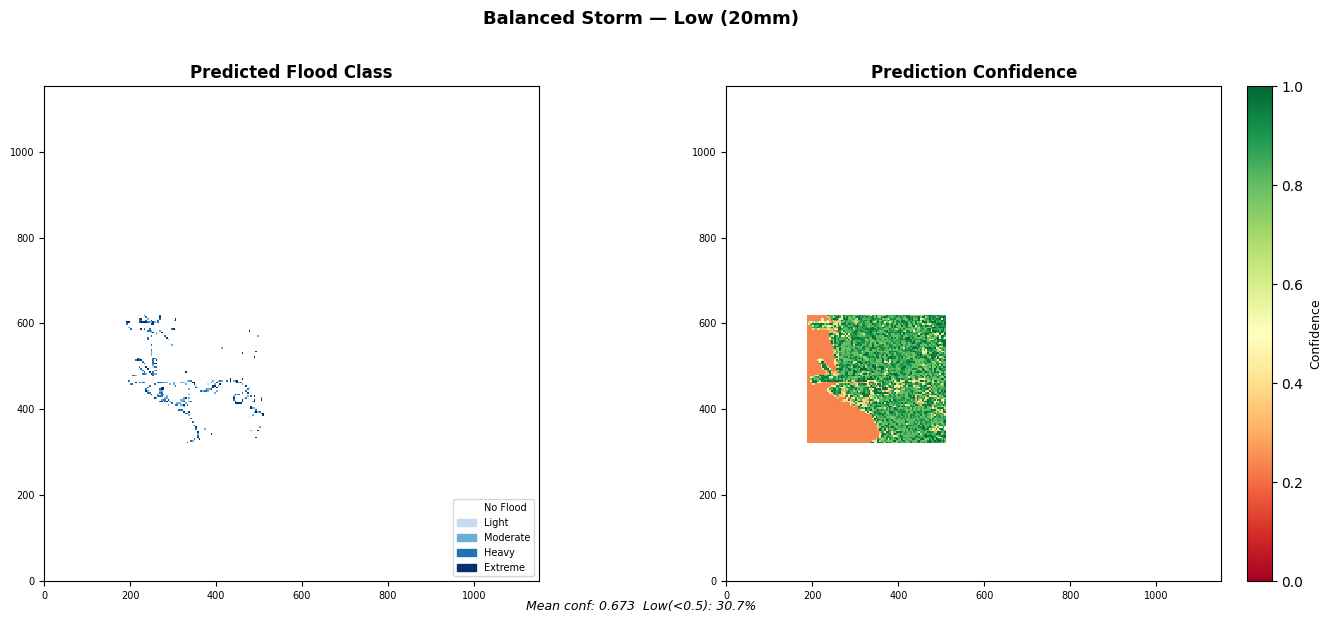

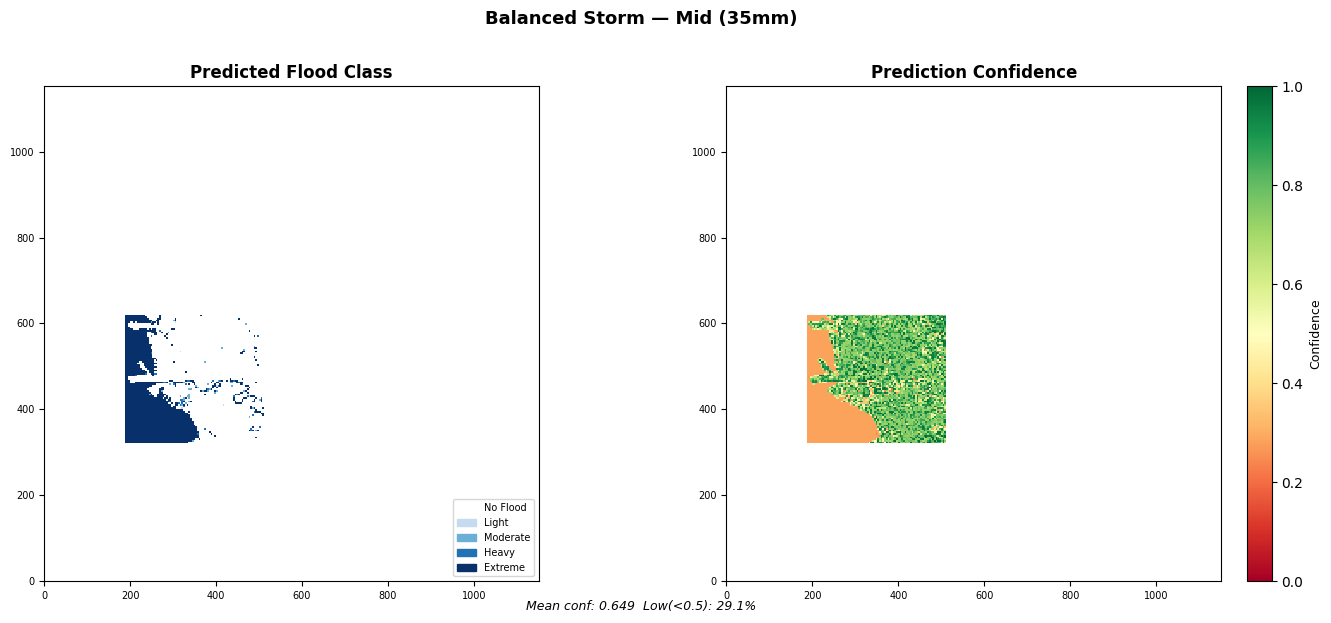

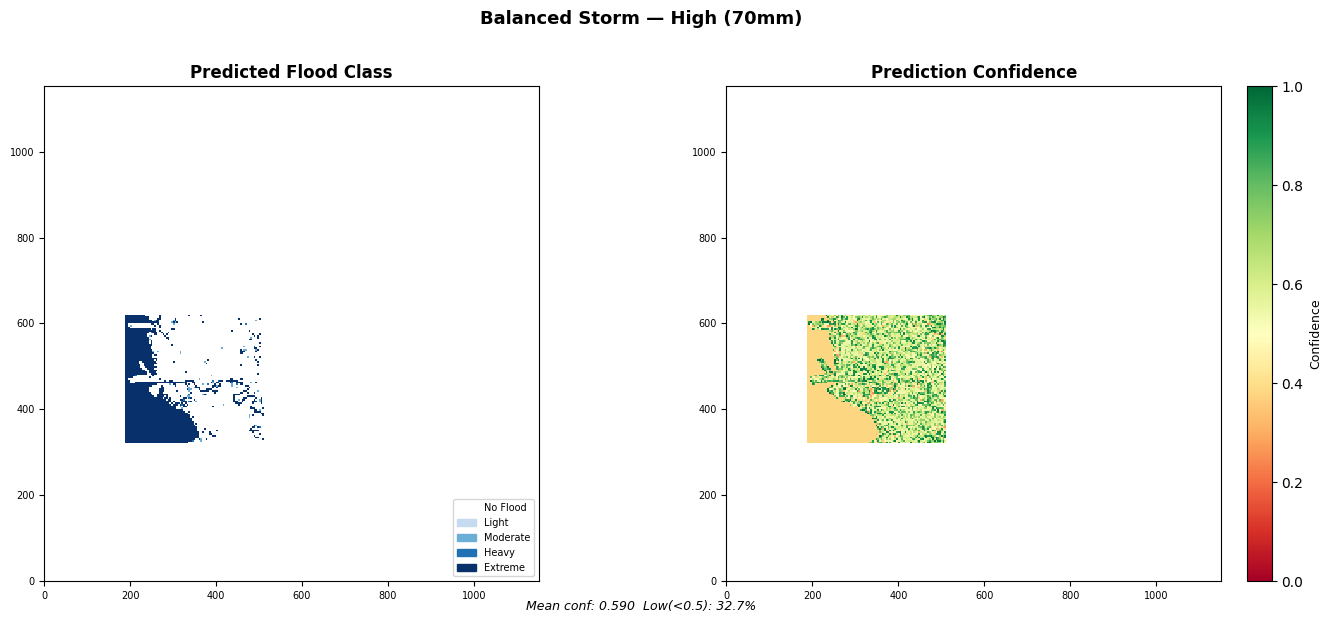

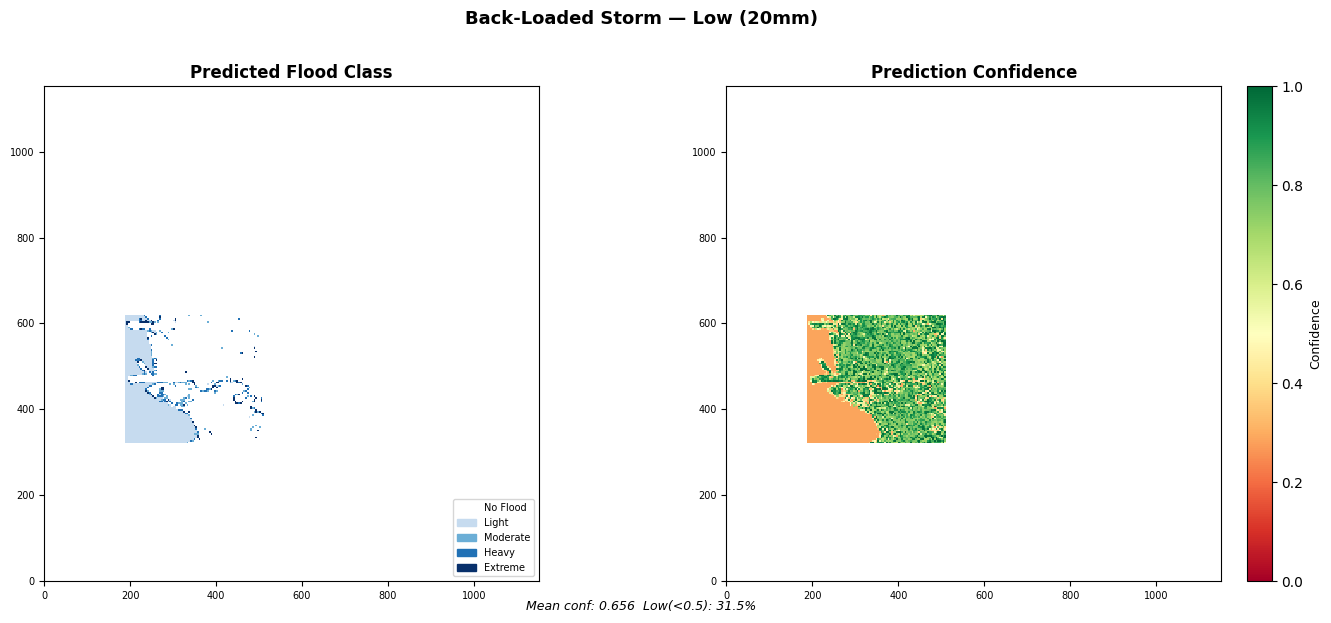

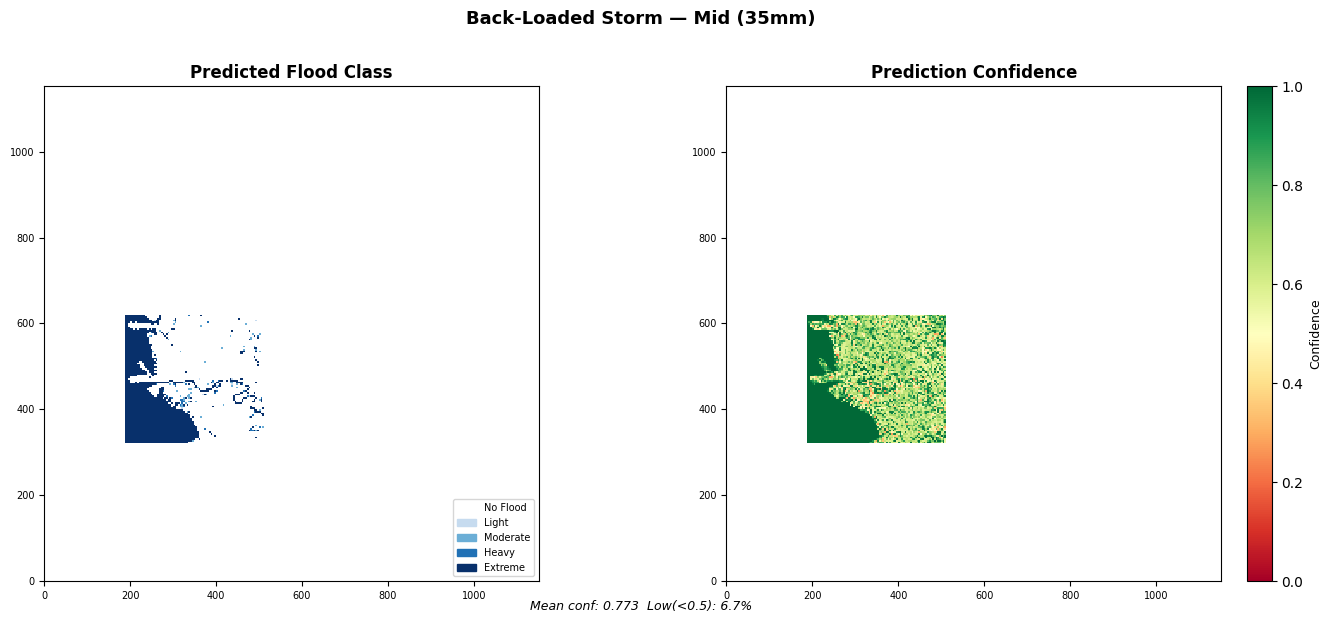

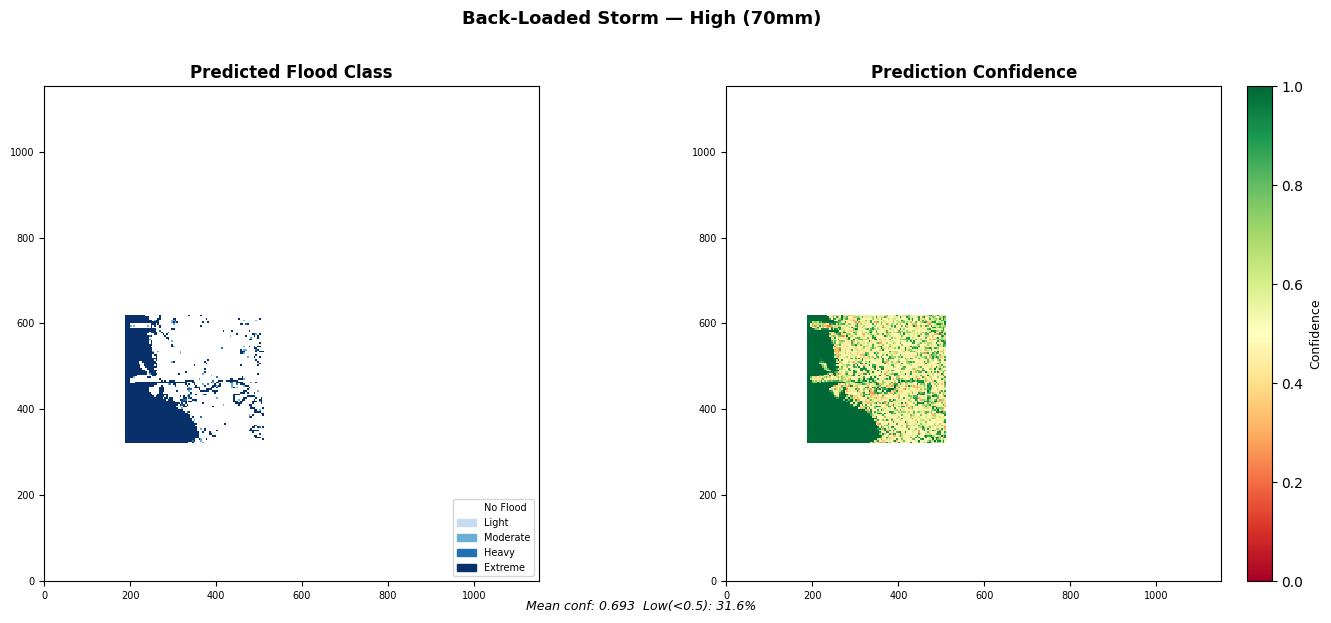

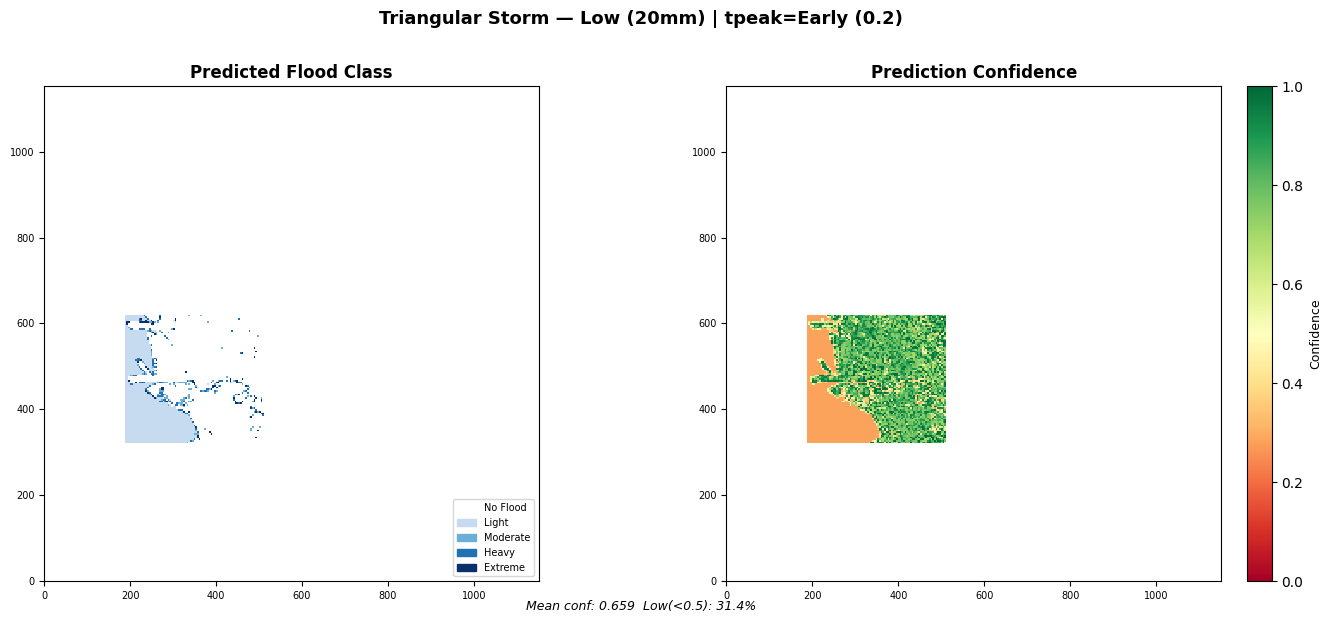

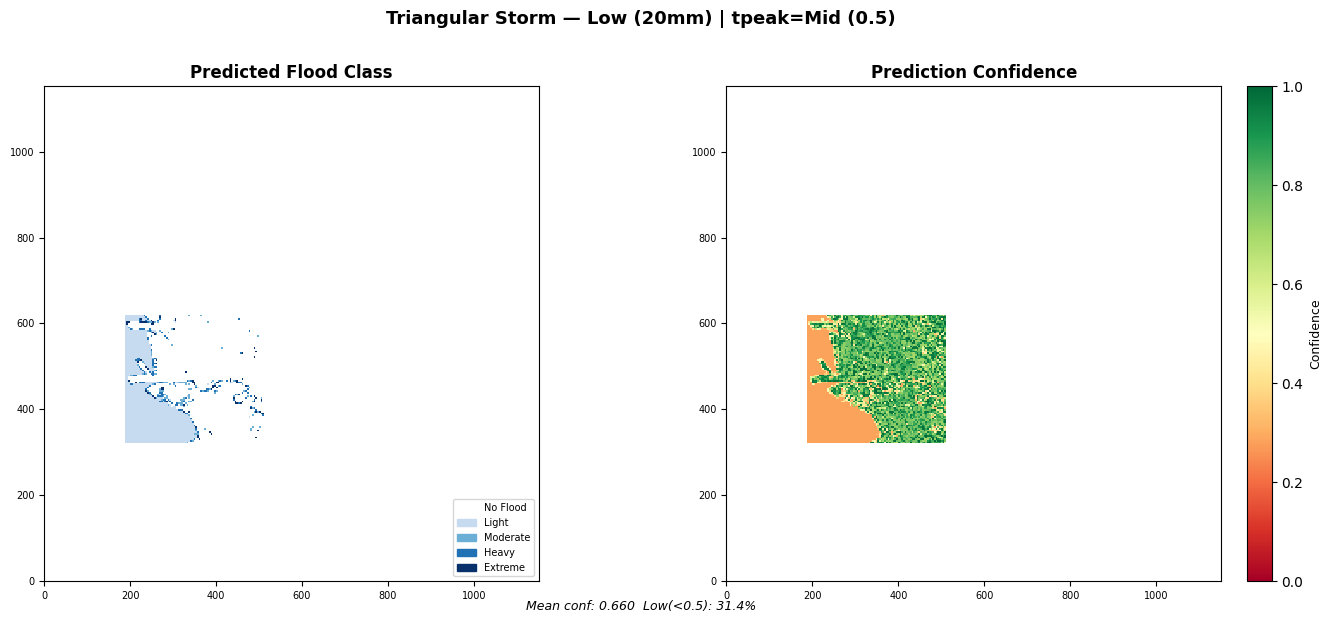

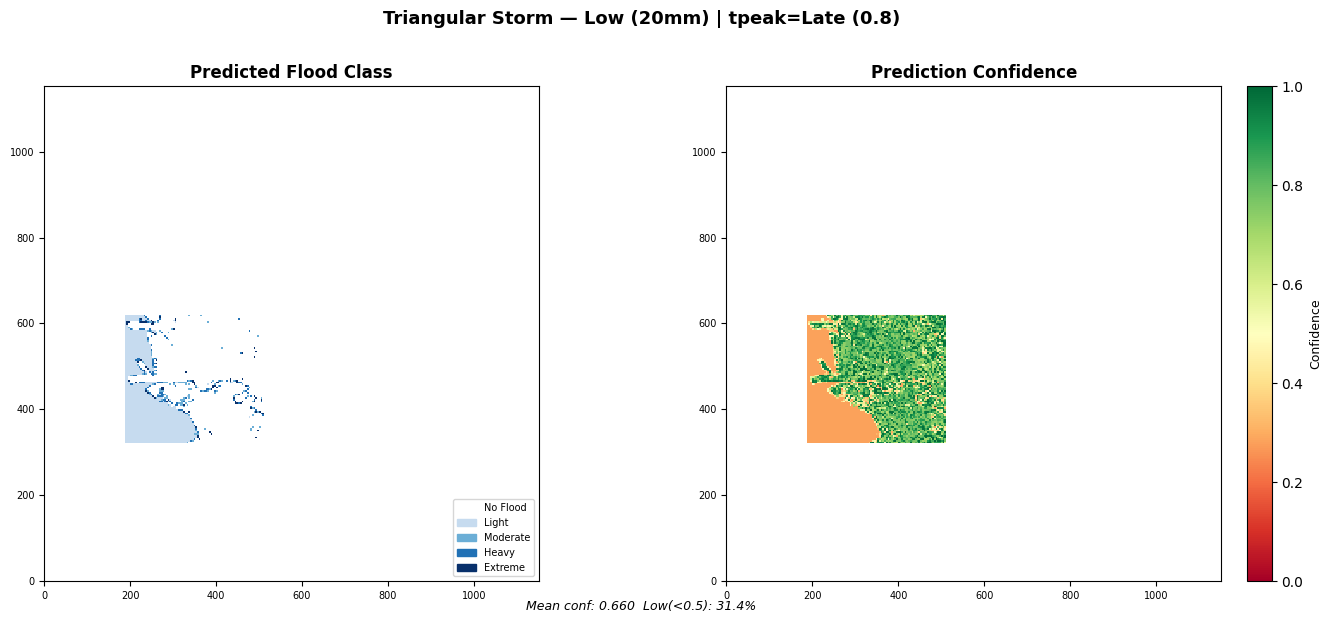

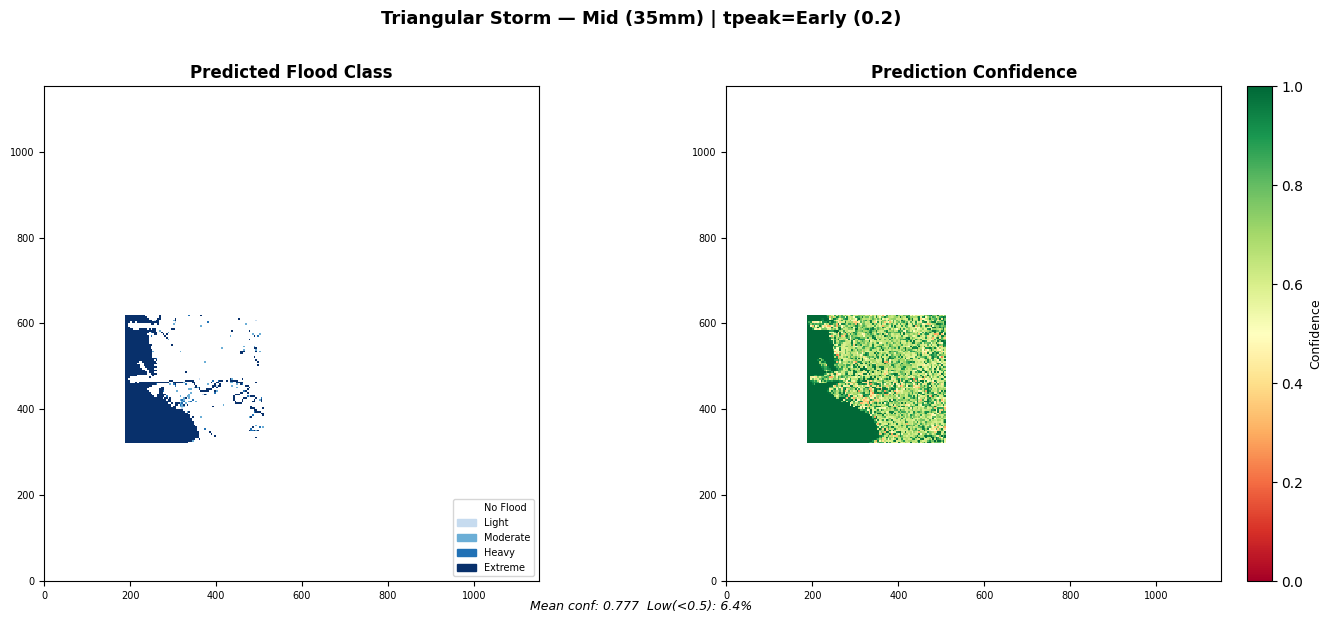

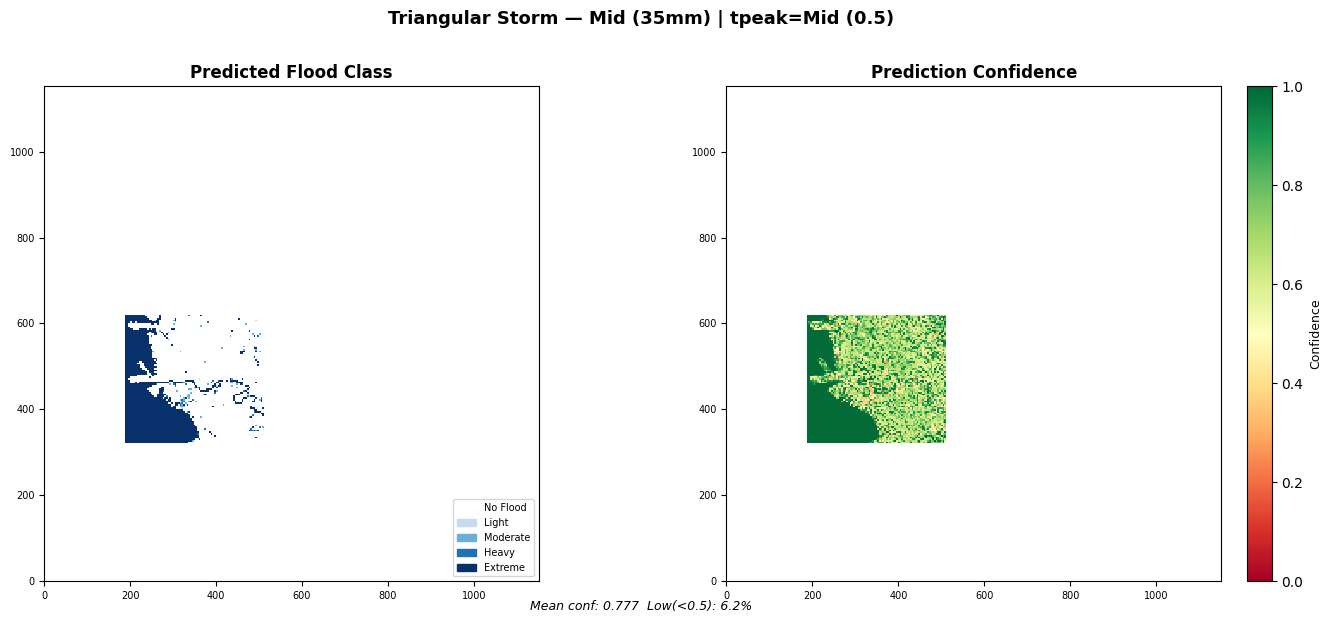

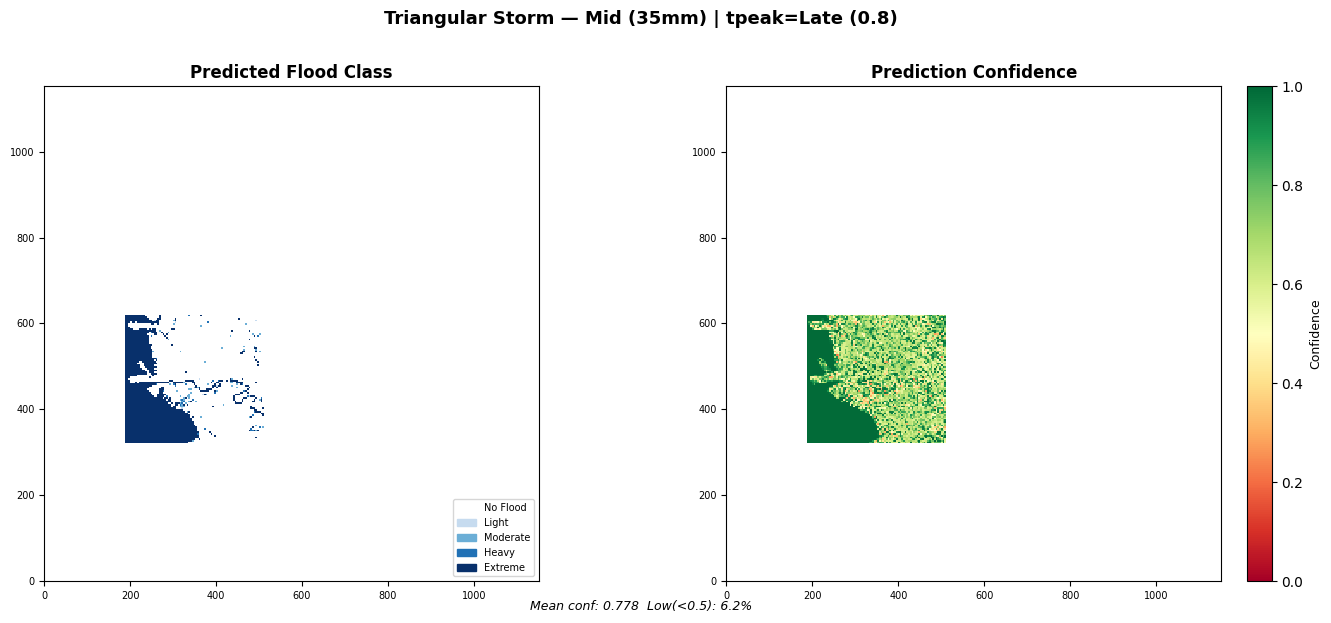

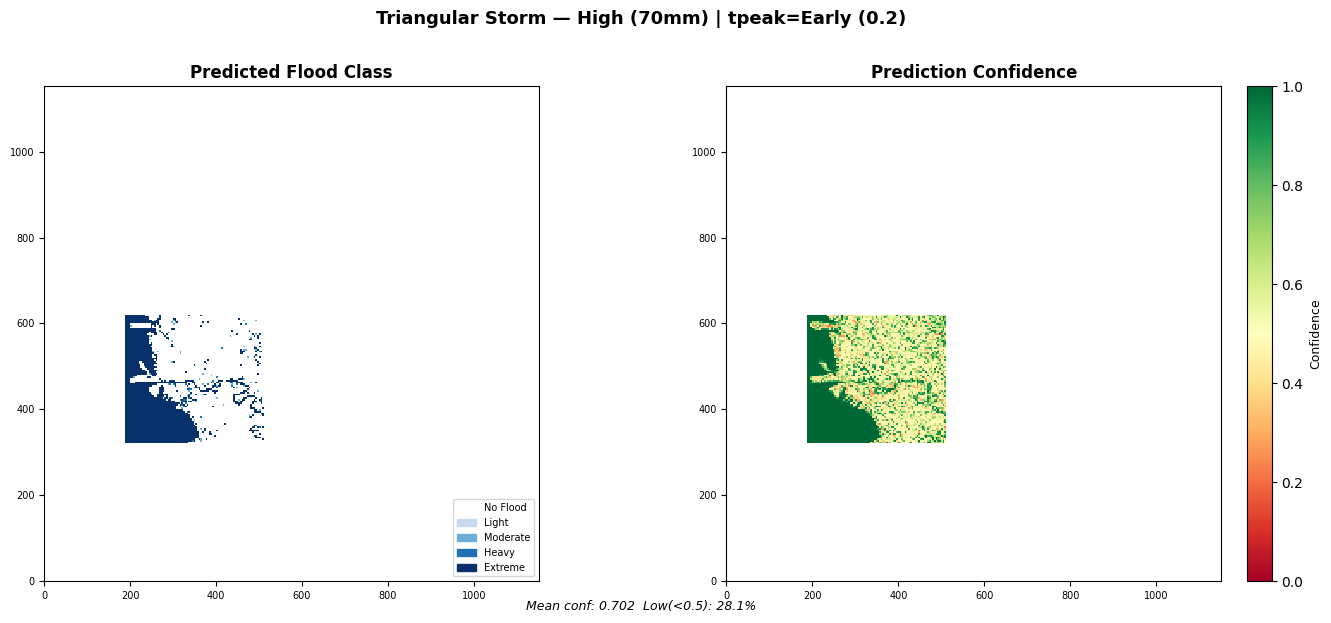

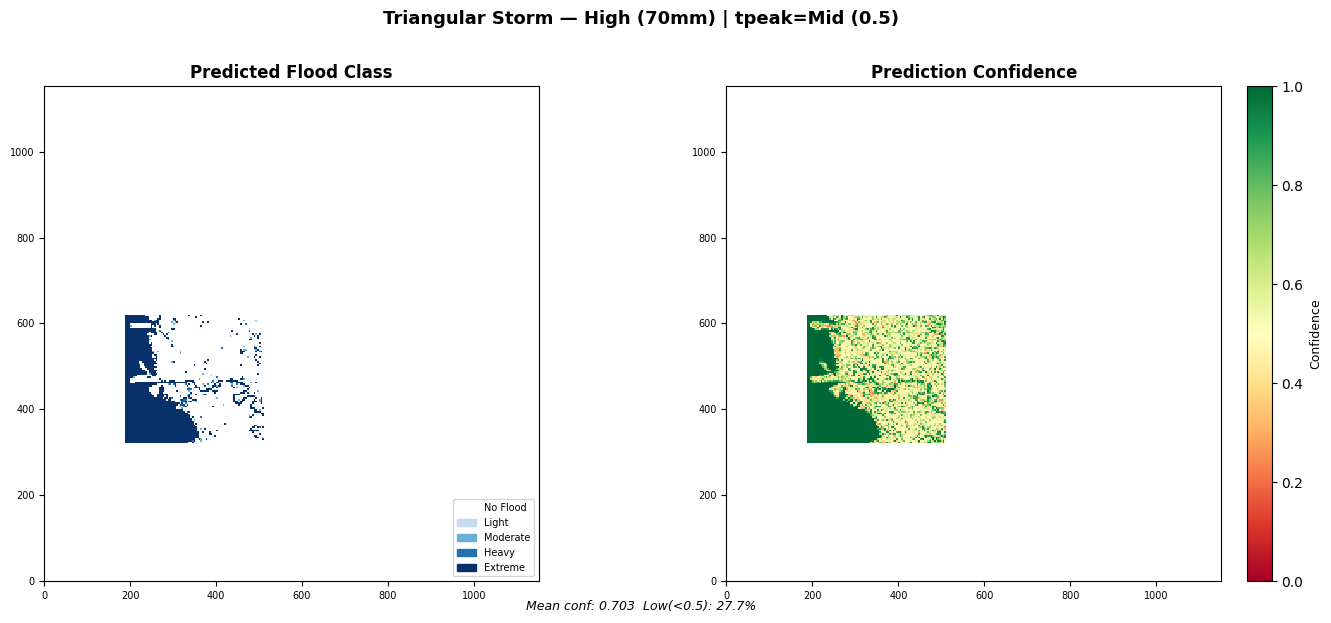

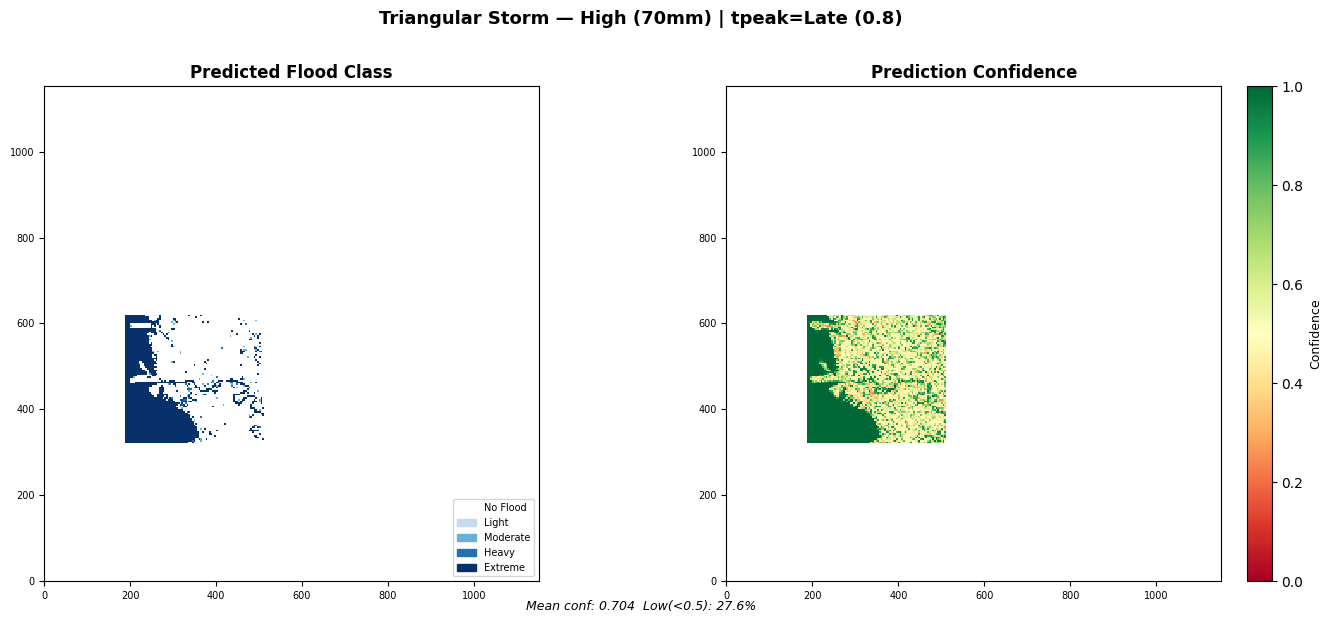

In [5]:
# ── Visualize all saved ablation TIFFs ───────────────────────────────────────

# Non-triangular: 3 storm types × 3 depths
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        slug  = f"{storm_type.replace('-','_')}_{depth}mm"
        tif   = str(output_dir / f'{slug}.tif')
        title = f"{storm_type.title()} Storm — {DEPTH_LABELS[depth]}"
        fig   = visualize_prediction_tiff(tif, title=title)
        plt.show()

# Triangular: 3 depths × 3 tpeaks
for depth in DEPTHS:
    for tpeak in TPEAKS:
        slug  = f"triangular_{depth}mm_tpeak{str(tpeak).replace('.','')}"
        tif   = str(output_dir / f'{slug}.tif')
        title = f"Triangular Storm — {DEPTH_LABELS[depth]} | tpeak={TPEAK_LABELS[tpeak]}"
        fig   = visualize_prediction_tiff(tif, title=title)
        plt.show()